Code for Subsection 3.4.1. Portfolio Allocation Problem.

**Usage Note**

This notebook uses `rpy2` to load the `danishmulti` dataset from the R package `CASdatasets`. Before running the code, please make sure that a working R environment is installed and properly configured on your system. You also need to install the required R package in R first:

```r
install.packages("CASdatasets")
```

In Python, ensure that `rpy2` is installed:

```bash
pip install rpy2
```

After both R and `CASdatasets` are available, the code will load the R package, import the `danishmulti` dataset, and convert it into a pandas DataFrame for further analysis in Python.

In [19]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter

from Algorithms import TamedSGHMC, TUSLA

# -----------------------------
# Data loading
# -----------------------------

ro.r('if (!requireNamespace("CASdatasets", quietly = TRUE)) stop("CASdatasets is not installed. Please install it in R first.")')
ro.r("library(CASdatasets)")
ro.r("data(danishmulti)")

with localconverter(default_converter + pandas2ri.converter):
    danishmulti = ro.conversion.rpy2py(ro.r("danishmulti"))

losses_matrix = danishmulti[["Building", "Contents", "Profits"]].to_numpy(dtype=float)
N, d = losses_matrix.shape
print(f"3D dataset shape: {losses_matrix.shape}")

# -----------------------------
# Shared CVaR setup
# -----------------------------
q, eta, beta, gamma, m, r = 0.95, 1e-3, 1e10, 3.0, 1e-3, 1.0
inv_tail = 1.0 / (1.0 - q)

def softmax(w):
    w = np.asarray(w, dtype=float)
    z = np.exp(w - np.max(w))
    return z / np.sum(z)

def objective_u_multi(theta_vec):
    theta_vec = np.asarray(theta_vec, dtype=float)
    theta, omega = float(theta_vec[0]), theta_vec[1:]
    g = softmax(omega)
    port = losses_matrix @ g
    return float(theta + np.mean(np.maximum(port - theta, 0.0)) / (1.0 - q) + 0.25 * eta * np.sum(theta_vec ** 2) ** 2)

def grad_objective_u_multi(theta_vec):
    theta_vec = np.asarray(theta_vec, dtype=float)
    theta, omega = float(theta_vec[0]), theta_vec[1:]

    g = softmax(omega)
    port = losses_matrix @ g

    indicator = (port >= theta).astype(float)
    norm_sq = float(np.sum(theta_vec ** 2))

    grad = np.empty(1 + d, dtype=float)

    # d/dtheta
    grad[0] = eta * norm_sq * theta + 1.0 - inv_tail * np.mean(indicator)

    # d/domega
    # For active samples: grad_omega port = g * (x - port)
    active_term = indicator[:, None] * g[None, :] * (losses_matrix - port[:, None])
    grad[1:] = eta * norm_sq * omega + inv_tail * np.mean(active_term, axis=0)

    return grad

def H_cvar_multi(theta_vec, x_sample):
    theta_vec, x_sample = np.asarray(theta_vec, dtype=float), np.asarray(x_sample, dtype=float)
    theta, omega = float(theta_vec[0]), theta_vec[1:]
    g = softmax(omega)
    port = float(np.dot(g, x_sample))
    indicator = 1.0 if port >= theta else 0.0
    norm_sq = float(np.sum(theta_vec ** 2))
    grad = np.empty(1 + d, dtype=float)
    grad[0] = eta * norm_sq * theta + 1.0 - inv_tail * indicator
    grad[1:] = eta * norm_sq * omega + inv_tail * indicator * g * (x_sample - port)
    return grad

def sample_xs(n_steps, rng):
    return losses_matrix[rng.integers(0, N, size=n_steps)]

3D dataset shape: (2167, 3)


In [20]:
# ============================================================
# Experiment 1: Expected excess risk using scipy.optimize minimizer
# ============================================================

# -----------------------------
# Compute numerical minimizer using Adam
# -----------------------------
def adam_minimize(
    objective,
    grad_objective,
    x0,
    lr=1e-2,
    n_iter=200000,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    tol=1e-10,
):
    x = np.asarray(x0, dtype=float).copy()
    m_adam = np.zeros_like(x)
    v_adam = np.zeros_like(x)

    best_x = x.copy()
    best_val = objective(x)

    prev_val = best_val

    for t in range(1, n_iter + 1):
        grad = grad_objective(x)

        m_adam = beta1 * m_adam + (1.0 - beta1) * grad
        v_adam = beta2 * v_adam + (1.0 - beta2) * (grad ** 2)

        m_hat = m_adam / (1.0 - beta1 ** t)
        v_hat = v_adam / (1.0 - beta2 ** t)

        x -= lr * m_hat / (np.sqrt(v_hat) + eps)

        val = objective(x)

        if val < best_val:
            best_val = val
            best_x = x.copy()

        if abs(prev_val - val) < tol:
            break

        prev_val = val

    return best_x, best_val, t


rng_opt = np.random.default_rng(12345)

initial_points = [
    np.zeros(1 + d),
    np.array([1.0, 0.0, 0.0, 0.0]),
    np.array([2.0, 0.0, 0.0, 0.0]),
    np.array([5.0, 0.0, 0.0, 0.0]),
]

initial_points += [
    np.concatenate(
        ([rng_opt.normal(0.0, 2.0)], rng_opt.normal(0.0, 2.0, size=d))
    )
    for _ in range(20)
]

theta_star = None
u_star = np.inf
best_iter = None

for x0 in initial_points:
    x_adam, val_adam, n_used = adam_minimize(
        objective_u_multi,
        grad_objective_u_multi,
        x0=x0,
        lr=1e-2,
        n_iter=200000,
        tol=1e-12,
    )

    if val_adam < u_star:
        theta_star = x_adam
        u_star = val_adam
        best_iter = n_used

print("\nNumerical minimizer from Adam:")
print(f"theta_star = {theta_star}")
print(f"u_star     = {u_star:.10f}")
print(f"iterations = {best_iter}")
print(f"portfolio weights = {softmax(theta_star[1:])}")

# -----------------------------
# Simulate expected excess risk paths
# -----------------------------
lr_plot = 5e-2
n_steps_plot = 10**4
n_repeats_plot = 100
seed_plot = 20260525

def draw_path_inputs(rep):
    rng = np.random.default_rng(seed_plot + rep)
    theta0 = np.concatenate(([rng.normal(0.0, 1.0)], rng.normal(0.0, 1.0, size=d)))
    xs = sample_xs(n_steps_plot, rng)
    return theta0, xs

def simulate_excess_paths(rep):
    theta0, xs = draw_path_inputs(rep)
    rng_tusla = np.random.default_rng(300000 + rep)
    rng_tamed = np.random.default_rng(400000 + rep)

    solver_tusla = TUSLA(H=H_cvar_multi, lr=lr_plot, beta=beta, r=r)
    path_tusla = np.asarray(solver_tusla.simulate(theta0=theta0, xs=xs, n_steps=n_steps_plot, rng=rng_tusla), dtype=float).reshape(-1, 1 + d)

    solver_tamed = TamedSGHMC(H=H_cvar_multi, lr=lr_plot, gamma=gamma, beta=beta, m=m, r=r)
    path_tamed, _ = solver_tamed.simulate(theta0=theta0, vol0=np.zeros(1 + d), xs=xs, n_steps=n_steps_plot, rng=rng_tamed)
    path_tamed = np.asarray(path_tamed, dtype=float).reshape(-1, 1 + d)

    excess_tusla = np.array([objective_u_multi(th) - u_star for th in path_tusla], dtype=float)
    excess_tamed = np.array([objective_u_multi(th) - u_star for th in path_tamed], dtype=float)
    return excess_tusla, excess_tamed

all_excess_tusla, all_excess_tamed = [], []
for rep in range(n_repeats_plot):
    ex_tusla, ex_tamed = simulate_excess_paths(rep)
    all_excess_tusla.append(ex_tusla)
    all_excess_tamed.append(ex_tamed)

excess_tusla_mat = np.stack(all_excess_tusla, axis=0)
excess_tamed_mat = np.stack(all_excess_tamed, axis=0)
mean_tusla = excess_tusla_mat.mean(axis=0)
mean_tamed = excess_tamed_mat.mean(axis=0)
se_tusla = excess_tusla_mat.std(axis=0, ddof=1) / np.sqrt(n_repeats_plot)
se_tamed = excess_tamed_mat.std(axis=0, ddof=1) / np.sqrt(n_repeats_plot)
iterations = np.arange(n_steps_plot + 1)

print("\n3D CVaR expected excess risk study:")
print(f"initial excess risk TUSLA  = {mean_tusla[0]:.6e}")
print(f"final excess risk TUSLA    = {mean_tusla[-1]:.6e}")
print(f"initial excess risk tSGHMC = {mean_tamed[0]:.6e}")
print(f"final excess risk tSGHMC   = {mean_tamed[-1]:.6e}")


Numerical minimizer from Adam:
theta_star = [ 0.91963093 -1.36949187 -1.86704965  3.23651066]
u_star     = 3.6423098705
iterations = 200000
portfolio weights = [0.00983368 0.00597902 0.9841873 ]

3D CVaR expected excess risk study:
initial excess risk TUSLA  = 2.273899e+01
final excess risk TUSLA    = 6.683498e-02
initial excess risk tSGHMC = 2.273899e+01
final excess risk tSGHMC   = 2.079597e-02


In [22]:
# ============================================================
# Experiment 2: Fixed-time log-log analysis
# ============================================================

# -----------------------------
# Fixed-time simulation helpers
# -----------------------------
T_end, h_min, h_max = 10.0, 5e-5, 5e-4
log_h_vals = np.linspace(np.log(h_min), np.log(h_max), 8)
step_sizes = np.exp(log_h_vals)
lr_ref_fixed = 1e-5
n_particles = 100

def draw_fixed_time_inputs(rep, n_steps):
    rng_data = np.random.default_rng(500000 + rep)
    rng_init = np.random.default_rng(510000 + rep)
    theta0 = np.concatenate(([rng_init.normal(0.0, 1.0)], rng_init.normal(0.0, 1.0, size=d)))
    xs = sample_xs(n_steps, rng_data)
    return theta0, xs

def simulate_terminal(rep, n_steps, lr_value, method):
    theta, xs = draw_fixed_time_inputs(rep, n_steps)
    if method == "tSGHMC":
        rng_alg = np.random.default_rng(520000 + rep)
        solver = TamedSGHMC(H=H_cvar_multi, lr=lr_value, gamma=gamma, beta=beta, m=m, r=r)
        vol = np.zeros_like(theta)
        for x in xs:
            theta, vol = solver.step(theta, vol, x, rng=rng_alg)
        return np.asarray(theta, dtype=float)
    if method == "TUSLA":
        rng_alg = np.random.default_rng(530000 + rep)
        solver = TUSLA(H=H_cvar_multi, lr=lr_value, beta=beta, r=r)
        for x in xs:
            theta = solver.step(theta, x, rng=rng_alg)
        return np.asarray(theta, dtype=float)
    raise ValueError("method must be either 'tSGHMC' or 'TUSLA'.")

def run_fixed_time(lr_value, method):
    n_steps = int(np.ceil(T_end / lr_value))
    terminals = []
    for rep in range(n_particles):
        terminals.append(simulate_terminal(rep, n_steps, lr_value, method))
    return np.asarray(terminals, dtype=float)

def coupled_rmse(terminals, ref_terminals):
    terminals = np.asarray(terminals, dtype=float)
    ref_terminals = np.asarray(ref_terminals, dtype=float)
    return float(np.sqrt(np.mean(np.sum((terminals - ref_terminals) ** 2, axis=1))))

# -----------------------------
# Run fixed-time log-log study
# -----------------------------
print("\nComputing fixed-time reference solutions...")
ref_tamed = run_fixed_time(lr_ref_fixed, "tSGHMC")
ref_tusla = run_fixed_time(lr_ref_fixed, "TUSLA")
print(f"tSGHMC reference mean: {ref_tamed.mean(axis=0)}")
print(f"TUSLA reference mean:  {ref_tusla.mean(axis=0)}")

rmse_tamed, rmse_tusla = [], []
print("\nSweeping step sizes...")
for h in step_sizes:
    n_steps = int(np.ceil(T_end / h))
    print(f"h={h:.2e}, n_steps={n_steps}...", end=" ")
    term_tamed = run_fixed_time(h, "tSGHMC")
    term_tusla = run_fixed_time(h, "TUSLA")
    rmse_t = coupled_rmse(term_tamed, ref_tamed)
    rmse_u = coupled_rmse(term_tusla, ref_tusla)
    rmse_tamed.append(rmse_t)
    rmse_tusla.append(rmse_u)
    print(f"RMSE: tSGHMC={rmse_t:.6e}, TUSLA={rmse_u:.6e}")

rmse_tamed = np.asarray(rmse_tamed, dtype=float)
rmse_tusla = np.asarray(rmse_tusla, dtype=float)
log_rmse_tamed = np.log(np.maximum(rmse_tamed, 1e-12))
log_rmse_tusla = np.log(np.maximum(rmse_tusla, 1e-12))
slope_tamed, intercept_tamed = np.polyfit(log_h_vals, log_rmse_tamed, deg=1)
slope_tusla, intercept_tusla = np.polyfit(log_h_vals, log_rmse_tusla, deg=1)

print(f"\nFixed-time log-log slope:")
print(f"tSGHMC slope = {slope_tamed:.4f}")
print(f"TUSLA slope  = {slope_tusla:.4f}")


Computing fixed-time reference solutions...
tSGHMC reference mean: [ 1.69120938 -0.61620217 -0.76382049  1.52135114]
TUSLA reference mean:  [ 0.97092645 -1.18038659 -1.65080793  2.95738217]

Sweeping step sizes...
h=5.00e-05, n_steps=200000... RMSE: tSGHMC=2.225438e-02, TUSLA=1.639009e-01
h=6.95e-05, n_steps=143938... RMSE: tSGHMC=2.798273e-02, TUSLA=2.003189e-01
h=9.65e-05, n_steps=103590... RMSE: tSGHMC=3.317507e-02, TUSLA=2.226254e-01
h=1.34e-04, n_steps=74552... RMSE: tSGHMC=3.850009e-02, TUSLA=2.485636e-01
h=1.86e-04, n_steps=53654... RMSE: tSGHMC=4.657708e-02, TUSLA=2.622569e-01
h=2.59e-04, n_steps=38614... RMSE: tSGHMC=5.631884e-02, TUSLA=2.877672e-01
h=3.60e-04, n_steps=27790... RMSE: tSGHMC=6.670406e-02, TUSLA=2.976351e-01
h=5.00e-04, n_steps=20000... RMSE: tSGHMC=7.228565e-02, TUSLA=3.244411e-01

Fixed-time log-log slope:
tSGHMC slope = 0.5200
TUSLA slope  = 0.2744


/var/folders/zr/c1gvt7sj571d4qckjh6yzmhc0000gn/T/ipykernel_7419/2003672702.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


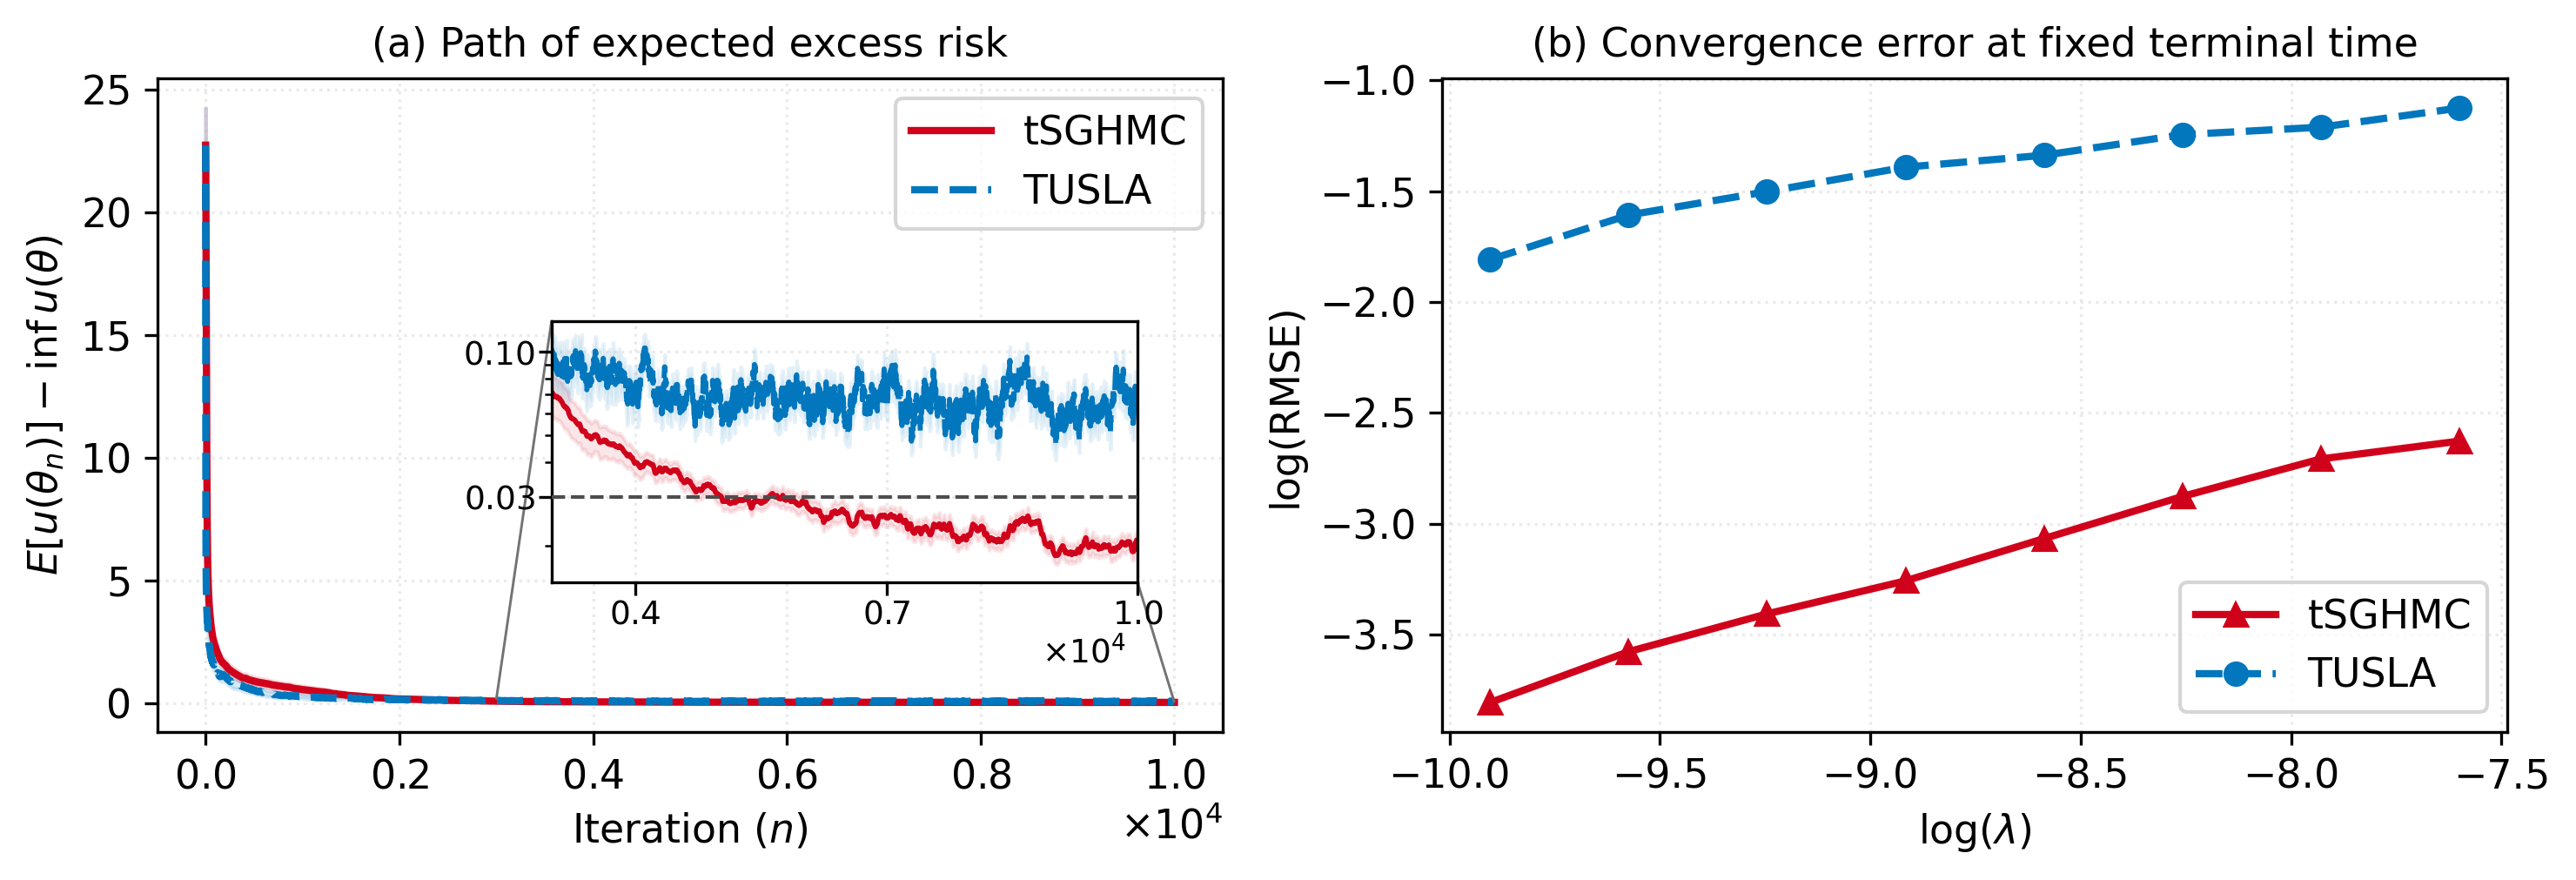

In [25]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import NullFormatter

# -----------------------------
# Combined plot
# -----------------------------
plt.rcParams.update({"font.size": 11, "axes.labelsize": 11, "axes.titlesize": 11, "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11})

mean_tusla_plot = np.maximum(mean_tusla, 0.0)
mean_tamed_plot = np.maximum(mean_tamed, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300)

# ax = axes[0]
# ax.plot(iterations, mean_tamed_plot, color="#d0021b", linewidth=2.0, label="tSGHMC")
# ax.fill_between(iterations, np.maximum(mean_tamed_plot - se_tamed, 0.0), mean_tamed_plot + se_tamed, color="#d0021b", alpha=0.15)
# ax.plot(iterations, mean_tusla_plot, color="#0277bd", linestyle="--", linewidth=2.0, label="TUSLA")
# ax.fill_between(iterations, np.maximum(mean_tusla_plot - se_tusla, 0.0), mean_tusla_plot + se_tusla, color="#0277bd", alpha=0.15)
# ax.set_yscale("log")
# ax.set_xlabel(r"Iteration ($n$)")
# ax.set_ylabel(r"$E[u(\theta_n)]-\inf u(\theta)$")
# ax.set_title("(a) Path of expected excess risk")
# ax.grid(alpha=0.25, linestyle=":")
# ax.legend(frameon=True)
# sf_iter = ScalarFormatter(useMathText=True)
# sf_iter.set_scientific(True)
# sf_iter.set_powerlimits((0, 0))
# ax.xaxis.set_major_formatter(sf_iter)
# ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

ax = axes[0]

eps_plot = 1e-8
mean_tusla_plot = np.maximum(mean_tusla, eps_plot)
mean_tamed_plot = np.maximum(mean_tamed, eps_plot)

lower_tamed = np.maximum(mean_tamed_plot - se_tamed, eps_plot)
upper_tamed = mean_tamed_plot + se_tamed
lower_tusla = np.maximum(mean_tusla_plot - se_tusla, eps_plot)
upper_tusla = mean_tusla_plot + se_tusla

ax.plot(iterations, mean_tamed_plot, color="#d0021b", linewidth=2.0, label="tSGHMC")
ax.fill_between(iterations, lower_tamed, upper_tamed, color="#d0021b", alpha=0.15)
ax.plot(iterations, mean_tusla_plot, color="#0277bd", linestyle="--", linewidth=2.0, label="TUSLA")
ax.fill_between(iterations, lower_tusla, upper_tusla, color="#0277bd", alpha=0.15)

# ax.set_yscale("log")
ax.set_xlabel(r"Iteration ($n$)")
ax.set_ylabel(r"$E[u(\theta_n)]-\inf u(\theta)$")
ax.set_title("(a) Path of expected excess risk")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, loc="upper right")

sf_iter = ScalarFormatter(useMathText=True)
sf_iter.set_scientific(True)
sf_iter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(sf_iter)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

# Inset: zoom in on late iterations
axins = inset_axes(ax, width="55%", height="40%", loc="lower right", bbox_to_anchor=(-0.05, 0.18, 1, 1), bbox_transform=ax.transAxes, borderpad=0.8)

zoom_start = 3000
zoom_end = iterations[-1]
mask = (iterations >= zoom_start) & (iterations <= zoom_end)

axins.plot(iterations[mask], mean_tamed_plot[mask], color="#d0021b", linewidth=1.4)
axins.fill_between(iterations[mask], lower_tamed[mask], upper_tamed[mask], color="#d0021b", alpha=0.10)
axins.plot(iterations[mask], mean_tusla_plot[mask], color="#0277bd", linestyle="--", linewidth=1.4)
axins.fill_between(iterations[mask], lower_tusla[mask], upper_tusla[mask], color="#0277bd", alpha=0.10)

axins.set_yscale("log")
threshold = 0.03
axins.axhline(threshold, color="#4D4D4D", linestyle="--", linewidth=1.0, zorder=3)
axins.set_xlim(zoom_start, zoom_end)

ymin = min(np.min(mean_tamed_plot[mask]), np.min(mean_tusla_plot[mask]))
ymax = max(np.max(mean_tamed_plot[mask]), np.max(mean_tusla_plot[mask]))
axins.set_ylim(max(ymin * 0.8, eps_plot), ymax * 1.25)

axins.grid(alpha=0.25, linestyle=":")
axins.tick_params(axis="both", labelsize=9, pad=1)

axins.set_xticks([4000, 7000, 10000])
axins.set_xticklabels([r"$0.4$", r"$0.7$", r"$1.0$"], fontsize=9)
axins.xaxis.get_offset_text().set_visible(False)

axins.text(0.98, -0.2, r"$\times 10^4$", transform=axins.transAxes, fontsize=9, ha="right", va="top")

axins.set_yticks([3e-2, 1e-1])
axins.set_yticklabels([r"$0.03$", r"$0.10$"], fontsize=9)
axins.yaxis.set_minor_formatter(NullFormatter())
axins.tick_params(axis="y", labelsize=9, pad=1)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.45", linewidth=0.7)

ax = axes[1]
ax.plot(log_h_vals, log_rmse_tamed, color="#d0021b", marker="^", linewidth=2.0, markersize=6.0, label="tSGHMC")
ax.plot(log_h_vals, log_rmse_tusla, color="#0277bd", marker="o", linestyle="--", linewidth=2.0, markersize=6.0, label="TUSLA")
ax.set_xlabel(r"$\log(\lambda)$")
ax.set_ylabel("log(RMSE)")
ax.set_title("(b) Convergence error at fixed terminal time")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, loc="best")

fig.tight_layout()
# fig.savefig("Example3_CVaR_3D.png", dpi=220, bbox_inches="tight")
plt.show()